Year         13472
Month        13472
Date         13472
Hour         13472
Min          13472
Sec          13472
PRN          13472
Elevation    13472
Azimuth      13472
SNR          13472
Label          945
dtype: int64
Year         0
Month        0
Date         0
Hour         0
Min          0
Sec          0
PRN          0
Elevation    0
Azimuth      0
SNR          0
Label        0
dtype: int64
        Elevation  Azimuth    SNR
1           14.09   177.32  40.22
2           14.10   177.31  40.51
3           14.10   177.30  40.84
4           14.11   177.29  41.04
5           14.12   177.28  41.28
...           ...      ...    ...
133559      49.26   319.97  50.55
133560      49.27   319.95  50.58
133561      49.29   319.94  50.66
133562      49.30   319.93  50.62
133563      49.31   319.92  50.64

[119148 rows x 3 columns]
1          LOS
2          LOS
3          LOS
4          LOS
5          LOS
          ... 
133559    NLOS
133560    NLOS
133561    NLOS
133562    NLOS
133563    NLOS


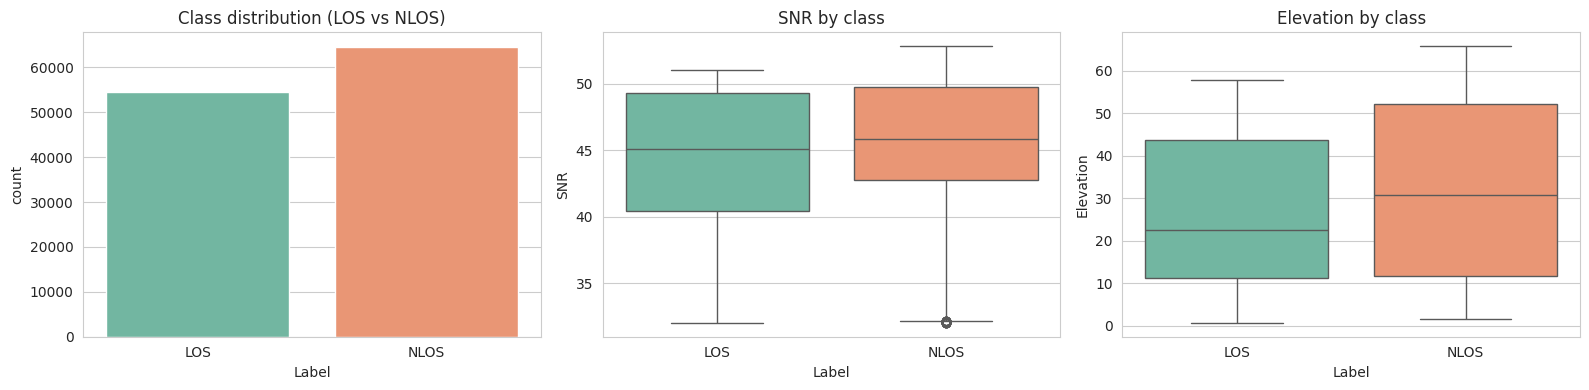

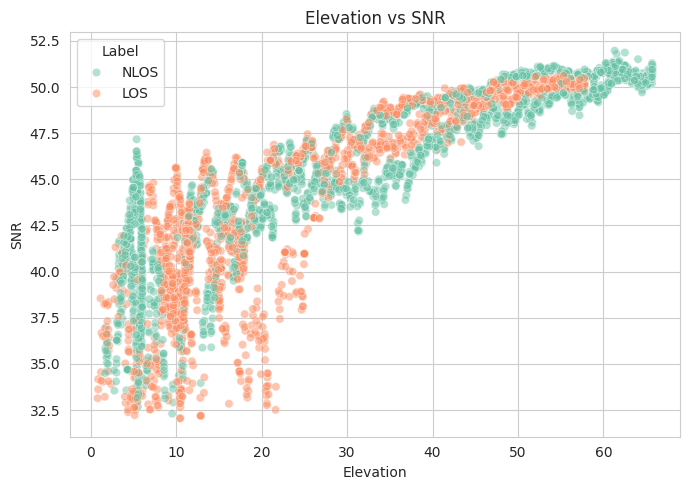

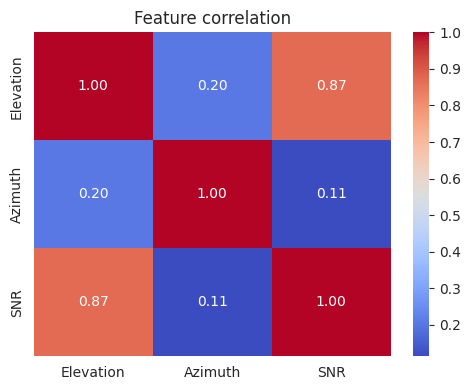

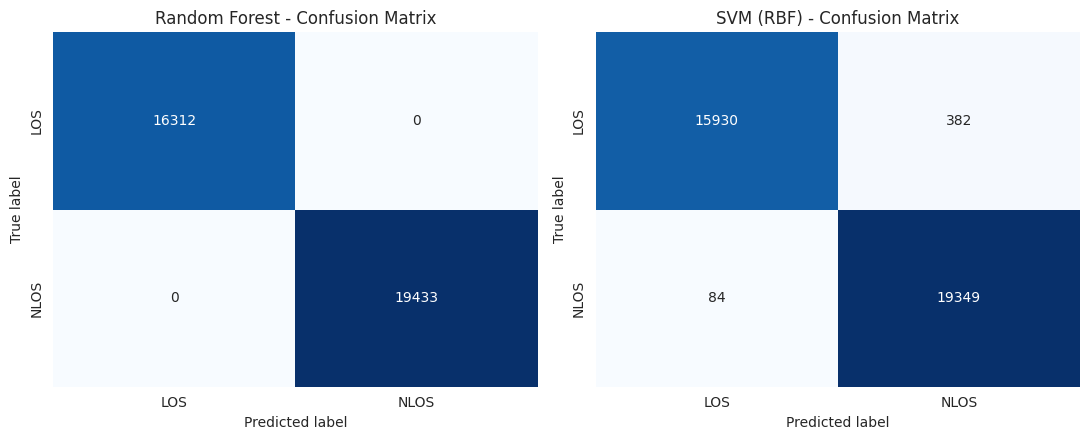

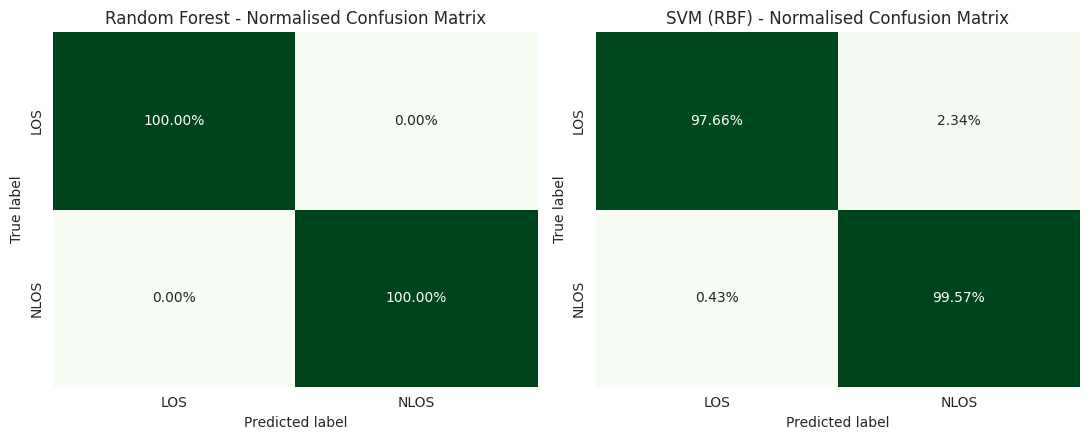


Model comparison:
               Accuracy  Precision  Recall  F1-score
Random Forest     1.000     1.0000   1.000     1.000
SVM (RBF)         0.987     0.9871   0.987     0.987


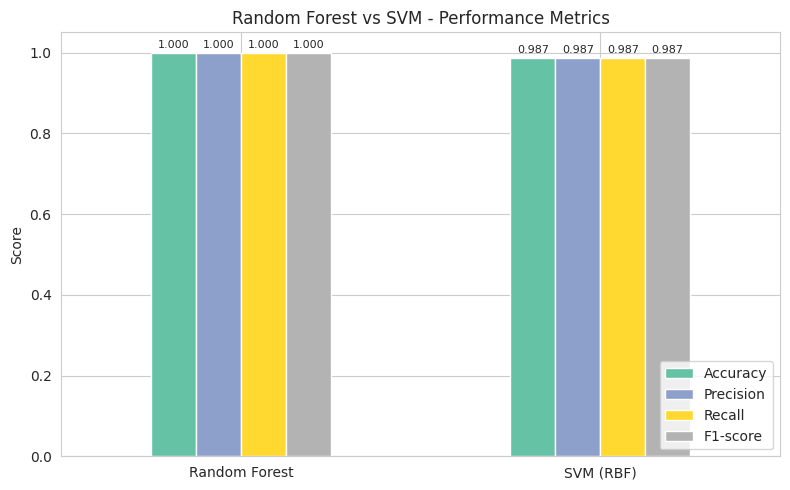

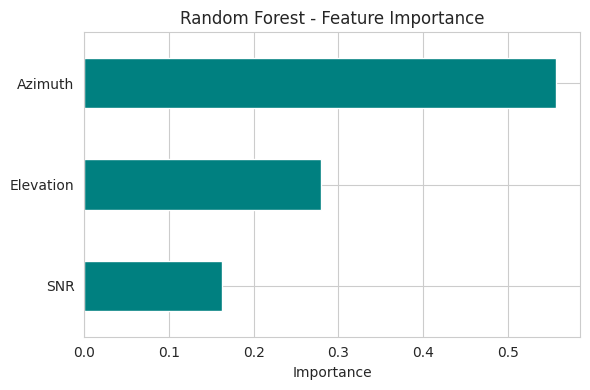

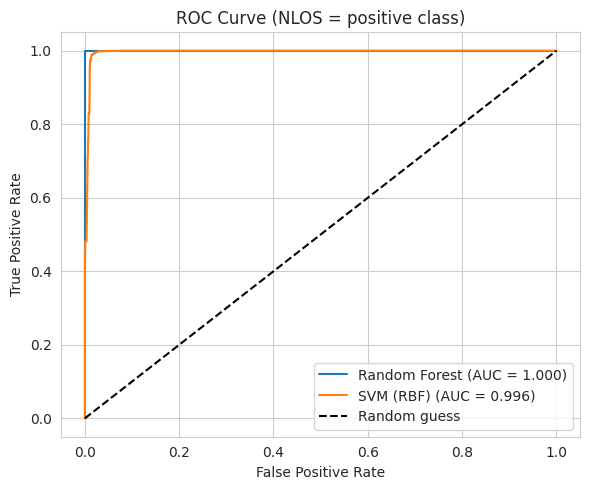

In [17]:
# -*- coding: utf-8 -*-
"""GNSS_data_RF_SVM.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1sH-ZZVvQ7L68SstTBNRrmSoj-44-aBQH

Updated: added plots for data exploration, confusion matrices, metrics comparison,
feature importance and ROC curves for both Random Forest and SVM.
"""

import os
import pandas as pd

df_g = pd.read_excel("gnss_data.xlsx")
df_g.head()

df_g.tail()

#Handling the Missing values...
#Verifying the columns with Missing values
print(df_g.isnull().sum())

# New dataset after removing the missing values
new_gnss = df_g.dropna(axis=0, how='any')

print(new_gnss.isnull().sum())

new_gnss.tail()

#Defining the features and targets of the data
X = new_gnss.iloc[:,7:10]
Y = new_gnss['Label']
print(X) #Features Vector
print(Y) #Target

# Handle the missing values then normalisation
#Lets scale or standardize the features
from sklearn.preprocessing import StandardScaler, MinMaxScaler
sc = MinMaxScaler()
X = sc.fit_transform(X)   #fit the data and transform it
print(X)

#Split the dataset into train and test set
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.30)
# test data size is 30% of entire data set

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=32)

# Train the model
rf_clf.fit(X_train, Y_train)

# Predict on test data
Y_pred_rf = rf_clf.predict(X_test)          # renamed so SVM does not overwrite it

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_rf))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_rf))

print(f"Accuracy: {accuracy_score(Y_test, Y_pred_rf):.2f}")

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline


# === Build and Train SVM Pipeline ===
pipeline = Pipeline([
    ('scaler', StandardScaler()),             # Feature scaling
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))  # SVM classifier
])

pipeline.fit(X_train, Y_train)

# === Predict and Evaluate ===
Y_pred_svm = pipeline.predict(X_test)       # renamed so RF predictions are kept

print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_svm))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_svm))

print("Accuracy: {:.2f}".format(accuracy_score(Y_test, Y_pred_svm)))


# =====================================================================
# VISUALIZATION OF RESULTS AND METRICS (new code)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_curve, auc)

os.makedirs("images", exist_ok=True)           # plots are saved here for the GitHub README
sns.set_style("whitegrid")

feature_names = list(new_gnss.columns[7:10])   # ['Elevation', 'Azimuth', 'SNR']
class_names = list(rf_clf.classes_)            # ['LOS', 'NLOS']


# ---------- 1. Data exploration plots ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Class balance
sns.countplot(x='Label', data=new_gnss, hue='Label', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title("Class distribution (LOS vs NLOS)")

# (b) SNR for each class
sns.boxplot(x='Label', y='SNR', data=new_gnss, hue='Label', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title("SNR by class")

# (c) Elevation for each class
sns.boxplot(x='Label', y='Elevation', data=new_gnss, hue='Label', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title("Elevation by class")

plt.tight_layout()
plt.savefig("images/data_exploration.png", dpi=150)
plt.show()

# Elevation vs SNR scatter (sample of 5000 points so the plot stays readable)
sample = new_gnss.sample(n=min(5000, len(new_gnss)), random_state=42)
plt.figure(figsize=(7, 5))
sns.scatterplot(x='Elevation', y='SNR', hue='Label', data=sample, alpha=0.5, palette='Set2')
plt.title("Elevation vs SNR")
plt.tight_layout()
plt.savefig("images/elevation_vs_snr.png", dpi=150)
plt.show()

# Correlation heatmap of the features
plt.figure(figsize=(5, 4))
sns.heatmap(new_gnss[feature_names].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature correlation")
plt.tight_layout()
plt.savefig("images/feature_correlation.png", dpi=150)
plt.show()


# ---------- 2. Confusion matrices (RF and SVM side by side) ----------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_pred) in zip(axes, [("Random Forest", Y_pred_rf), ("SVM (RBF)", Y_pred_svm)]):
    cm = confusion_matrix(Y_test, y_pred, labels=class_names)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig("images/confusion_matrices.png", dpi=150)
plt.show()

# Normalised version (each row shows percentage of that true class)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, y_pred) in zip(axes, [("Random Forest", Y_pred_rf), ("SVM (RBF)", Y_pred_svm)]):
    cm = confusion_matrix(Y_test, y_pred, labels=class_names, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Greens', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{name} - Normalised Confusion Matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig("images/confusion_matrices_normalised.png", dpi=150)
plt.show()


# ---------- 3. Metrics table and bar chart ----------
def get_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall":    recall_score(y_true, y_pred, average='weighted'),
        "F1-score":  f1_score(y_true, y_pred, average='weighted'),
    }

results = pd.DataFrame({
    "Random Forest": get_metrics(Y_test, Y_pred_rf),
    "SVM (RBF)":     get_metrics(Y_test, Y_pred_svm),
}).T.round(4)

print("\nModel comparison:")
print(results)
results.to_csv("images/model_comparison.csv")   # handy for the README results table

ax = results.plot(kind='bar', figsize=(8, 5), colormap='Set2', rot=0)
ax.set_ylim(0, 1.05)
ax.set_title("Random Forest vs SVM - Performance Metrics")
ax.set_ylabel("Score")
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("images/metrics_comparison.png", dpi=150)
plt.show()


# ---------- 4. Random Forest feature importance ----------
importances = pd.Series(rf_clf.feature_importances_, index=feature_names).sort_values()
plt.figure(figsize=(6, 4))
importances.plot(kind='barh', color='teal')
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=150)
plt.show()


# ---------- 5. ROC curves for both models ----------
y_true_bin = (Y_test == 'NLOS').astype(int)                      # NLOS = positive class
rf_scores  = rf_clf.predict_proba(X_test)[:, class_names.index('NLOS')]
svm_scores = pipeline.decision_function(X_test)                  # larger value = more NLOS

plt.figure(figsize=(6, 5))
for name, scores in [("Random Forest", rf_scores), ("SVM (RBF)", svm_scores)]:
    fpr, tpr, _ = roc_curve(y_true_bin, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (NLOS = positive class)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curves.png", dpi=150)
plt.show()